# Correlation example

- previously correlation was based on whole trace
- D.G. used different analysis during his NO experiments where he correlated certain response features from the chirp stimulus
- will be done here for an example

In [2]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [3]:
df = pd.read_pickle("../datasets/Averages_gChirp_C1C2DETANO.pkl")
df

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,preprocess_id,average,average_norm,average_t0,average_dt,triggertimes_rel,qidx,min_qidx
0,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,1,1,"[0.23404275666265387, 0.2381303010000348, 0.24...","[0.13093252217697324, 0.13321925173543125, 0.1...",0.0,0.002,"[0.0, 4.9980016]",0.306987,0.2
1,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,2,1,"[0.8592742807976649, 0.862168467678105, 0.8650...","[0.48455278264264817, 0.48618484162281833, 0.4...",0.0,0.002,"[0.0, 4.9980016]",0.397395,0.2
2,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,3,1,"[0.9966721981509353, 0.9982692731988386, 0.999...","[0.501599497802753, 0.5024032646214401, 0.5032...",0.0,0.002,"[0.0, 4.9980016]",0.442943,0.2
3,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,4,1,"[-0.11012223462448449, -0.11653696637358568, -...","[-0.06841417883949284, -0.07239937407810096, -...",0.0,0.002,"[0.0, 4.9980016]",0.267124,0.2
4,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,5,1,"[1.0140207452784273, 1.014220858071091, 1.0144...","[0.5124799892216649, 0.5125811250241669, 0.512...",0.0,0.002,"[0.0, 4.9980016]",0.239614,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3779,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,183,1,"[0.8112028982575517, 0.7867748997893866, 0.773...","[0.3587111864995656, 0.34790920794013624, 0.34...",0.0,0.002,"[0.0, 4.9971995]",0.331610,0.2
3780,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,184,1,"[1.2339049363468084, 1.2414545536000525, 1.245...","[0.5019784434913204, 0.5050497863525937, 0.506...",0.0,0.002,"[0.0, 4.9971995]",0.448928,0.2
3781,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,185,1,"[0.1381078234772653, 0.142473841751133, 0.1468...","[0.06722641006479439, 0.069351646184222, 0.071...",0.0,0.002,"[0.0, 4.9971995]",0.294794,0.2
3782,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,186,1,"[0.4181908417071479, 0.4380852987568168, 0.457...","[0.15175416080599652, 0.15897351219575662, 0.1...",0.0,0.002,"[0.0, 4.9971995]",0.336143,0.2


In [45]:
date = datetime.date(2025, 9, 8)
date_str = date.strftime("%Y%m%d")
field = "XY3"
roi = 5

df_filtered = df[
    (df["date"] == date) &
    (df["field"] == field) &
    (df["roi_id"] == roi)
]

df_filtered

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,preprocess_id,average,average_norm,average_t0,average_dt,triggertimes_rel,qidx,min_qidx
378,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,C1,5,1,"[-0.7522733767481632, -0.743453668170805, -0.7...","[-0.19826528317796616, -0.19594080636849048, -...",0.0,0.002,"[0.0, 4.996399]",0.637443,0.2
512,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,C2,5,1,"[0.36176648754594803, 0.3561538214559283, 0.35...","[0.20580295545044733, 0.20261000278886102, 0.1...",0.0,0.002,"[0.0, 4.9964]",0.239320,0.2


In [46]:
traces = df_filtered["average_norm"].to_numpy()
traces[0].shape

(16516,)

(-825.75, 17340.75, -0.8368545114935163, 1.087469262452072)

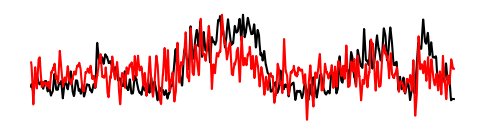

In [47]:
fig, axs = plt.subplots(1,1, figsize=(6,1.5))

axs.plot(traces[0], color="k")
axs.plot(traces[1], color="r")

axs.axis("off")

## Definition of chirp features

- currently based on the analysis from D.G.

In [48]:
sf = 500

on_feat_idx = [round(sf*2),round(sf*5)]
off_feat_idx = [round(sf*5),round(sf*8)]
low_freq_feat_idx = [round(sf*10),round(sf*13)]
high_freq_feat_idx = [round(sf*15),round(sf*18)]
low_cont_feat_idx = [round(sf*20),round(sf*23)]
high_cont_feat_idx = [round(sf*25),round(sf*28)]

(-825.75, 17340.75, -0.8368545114935163, 1.087469262452072)

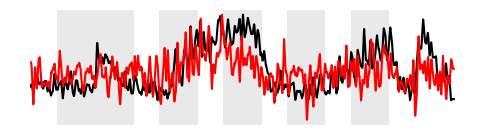

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(6, 1.5))

ax.plot(traces[0], color="k")
ax.plot(traces[1], color="r")

# Shaded feature intervals
alpha = 0.25

for start, end in [
    on_feat_idx,
    off_feat_idx,
    low_freq_feat_idx,
    high_freq_feat_idx,
    low_cont_feat_idx,
    high_cont_feat_idx,
]:
    ax.axvspan(
        start,
        end,
        color="darkgray",
        alpha=alpha,
        linewidth=0
    )

ax.axis("off")

In [50]:
features = {
    "on": on_feat_idx,
    "off": off_feat_idx,
    "low_freq": low_freq_feat_idx,
    "high_freq": high_freq_feat_idx,
    "low_cont": low_cont_feat_idx,
    "high_cont": high_cont_feat_idx,
}

clipped_traces = {}

for name, (start, end) in features.items():
    clipped_traces[name] = {
        "trace0": traces[0][start:end],
        "trace1": traces[1][start:end],
    }

In [51]:
clipped_traces

{'on': {'trace0': array([-0.24763628, -0.24758261, -0.24752894, ..., -0.21528942,
         -0.21637691, -0.2174644 ]),
  'trace1': array([-0.03329723, -0.03496362, -0.03663001, ..., -0.16205148,
         -0.1656651 , -0.16927873])},
 'off': {'trace0': array([-0.2185519 , -0.21963939, -0.21946089, ..., -0.23617629,
         -0.23110804, -0.22603978]),
  'trace1': array([-0.17289236, -0.17650599, -0.18011961, ..., -0.04558664,
         -0.03686045, -0.02994966])},
 'low_freq': {'trace0': array([-0.2168216 , -0.21504169, -0.21326178, ...,  0.66689374,
          0.66185735,  0.65682096]),
  'trace1': array([-0.28213199, -0.28981963, -0.29750726, ...,  0.16826565,
          0.16492756,  0.16158946])},
 'high_freq': {'trace0': array([0.73594138, 0.73346597, 0.73099056, ..., 0.33972456, 0.33837883,
         0.33703311]),
  'trace1': array([0.77605882, 0.77109285, 0.76612689, ..., 0.11730256, 0.11492079,
         0.11253902])},
 'low_cont': {'trace0': array([-0.1720033 , -0.17245062, -0.172897

In [52]:
# Calculate correlation for each feature
correlations = {}

for name, (start, end) in features.items():
    trace0_feature = traces[0][start:end]
    trace1_feature = traces[1][start:end]

    r = np.corrcoef(trace0_feature, trace1_feature)[0, 1]
    correlations[name] = r

print(correlations)

{'on': 0.11864316772628285, 'off': 0.029719135015310785, 'low_freq': 0.4356351788017591, 'high_freq': 0.10842230203724296, 'low_cont': 0.040742812259156776, 'high_cont': 0.25724589975052414}


In [53]:
# Mean and standard deviation across features
mean_r = np.mean(list(correlations.values()))
std_r = np.std(list(correlations.values()))

print(f"{mean_r} +- {std_r}")

0.16506808259837943 +- 0.1419174825710878


In [54]:
deltas = {}

for name, (start, end) in features.items():

    trace0_feature = traces[0][start:end]
    trace1_feature = traces[1][start:end]

    diff = np.mean(trace1_feature) - np.mean(trace0_feature)

    deltas[name] = diff

print(deltas)

{'on': 0.20440777790877607, 'off': -0.05750249587843286, 'low_freq': 0.006013068108497818, 'high_freq': -0.44653763689446263, 'low_cont': 0.16762203499918443, 'high_cont': -0.22930782084033924}


In [43]:
mean_delta = np.mean(list(deltas.values()))
std_delta = np.std(list(deltas.values()))

print(f"{mean_delta} +- {std_delta}")

0.2072535390100558 +- 0.3085843009008812


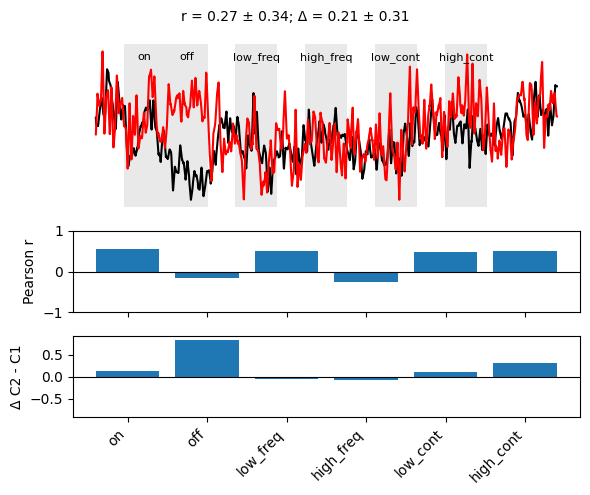

In [44]:
# Plot
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(6, 5),
    gridspec_kw={"height_ratios": [2, 1, 1]}
)

# =========================
# Original traces
# =========================
ax1.plot(traces[0], color="k")
ax1.plot(traces[1], color="r")

# Feature shading + labels
for name, (start, end) in features.items():

    ax1.axvspan(
        start,
        end,
        color="darkgray",
        alpha=0.25,
        linewidth=0
    )

    ax1.text(
        (start + end) / 2,
        0.95,
        name,
        transform=ax1.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=8
    )

ax1.axis("off")


# =========================
# Correlations
# =========================
ax2.bar(
    list(correlations.keys()),
    list(correlations.values())
)

ax2.axhline(0, color="k", linewidth=0.8)
ax2.set_ylabel("Pearson r")
ax2.set_ylim(-1, 1)

# Remove x-axis labels here since they will be shown below
ax2.tick_params(axis="x", labelbottom=False)


# =========================
# Delta values
# =========================
ax3.bar(
    list(deltas.keys()),
    list(deltas.values())
)

max_delta = max(abs(v) for v in deltas.values())

ax3.set_ylim(-max_delta * 1.1, max_delta * 1.1)

ax3.axhline(0, color="k", linewidth=0.8)
ax3.set_ylabel("Δ C2 - C1")
ax3.set_xticks(range(len(deltas)))
ax3.set_xticklabels(
    list(deltas.keys()),
    rotation=45,
    ha="right"
)


# =========================
# Overall title
# =========================
fig.suptitle(
    f"r = {mean_r:.2f} ± {std_r:.2f}; Δ = {mean_delta:.2f} ± {std_delta:.2f}",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    f"../plots/correlation_analysis/{date_str}_{field}_ROI{roi}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()